In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

games = pd.read_csv(r"C:\Users\l3anp\OneDrive\Desktop\inst414\nba_dataset_inst414\Cleaned_Games.csv")
games.head()

,gameId,gameDate,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,winner,gameType,attendance,arenaId,gameLabel,gameSubLabel,seriesGameNumber
0,42400407,6/22/2025 20:00,Oklahoma City,Thunder,1610612760,Indiana,Pacers,1610612754,103,91,1610612760,Playoffs,18203,1000052,NBA Finals,Game 7,7.0
1,42400406,6/19/2025 20:30,Indiana,Pacers,1610612754,Oklahoma City,Thunder,1610612760,108,91,1610612754,Playoffs,17274,1000063,NBA Finals,Game 6,6.0
2,42400405,6/16/2025 20:30,Oklahoma City,Thunder,1610612760,Indiana,Pacers,1610612754,120,109,1610612760,Playoffs,18203,1000052,NBA Finals,Game 5,5.0
3,42400404,6/13/2025 20:30,Indiana,Pacers,1610612754,Oklahoma City,Thunder,1610612760,104,111,1610612760,Playoffs,17274,1000063,NBA Finals,Game 4,4.0
4,42400403,6/11/2025 20:30,Indiana,Pacers,1610612754,Oklahoma City,Thunder,1610612760,116,107,1610612754,Playoffs,17274,1000063,NBA Finals,Game 3,3.0


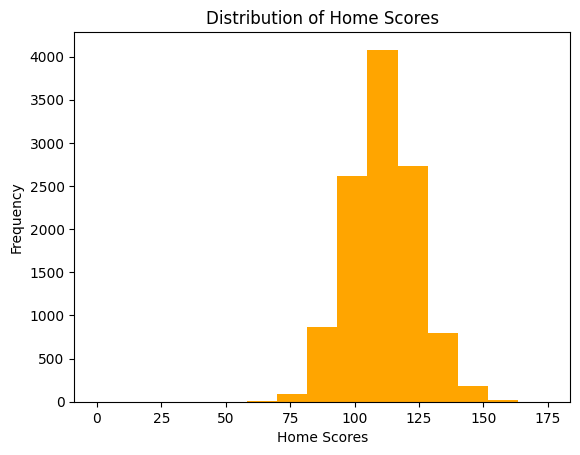

In [4]:
# histogram of home scores
plt.hist(games['homeScore'], bins=15, color='orange')

plt.title('Distribution of Home Scores')
plt.xlabel('Home Scores')
plt.ylabel('Frequency')
plt.show()

**Figure 1. Distribution of Home Team Scores.**
This figure represents a fairly normal distribution and shows that most teams tend to score between 100-120 points

In [5]:
# summary of figure 1 statistics
games['homeScore'].describe()

count    11388.000000
mean       110.978837
std         12.914578
min          0.000000
25%        102.000000
50%        111.000000
75%        120.000000
max        175.000000
Name: homeScore, dtype: float64

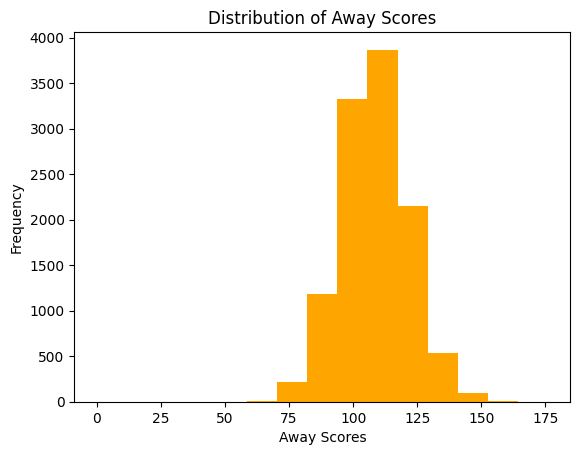

In [6]:
# histogram of away scores
plt.hist(games['awayScore'], bins=15, color='orange')

plt.title('Distribution of Away Scores')
plt.xlabel('Away Scores')
plt.ylabel('Frequency')
plt.show()

**Figure 2. Distribution of Away Team Scores.**
This figure represents a fairly normal distribution and shows that most away teams tend to score around 100-115 points

In [7]:
# summary of figure 2 statistics
games['awayScore'].describe()

count    11388.000000
mean       108.540920
std         13.079379
min          0.000000
25%        100.000000
50%        108.000000
75%        117.000000
max        176.000000
Name: awayScore, dtype: float64

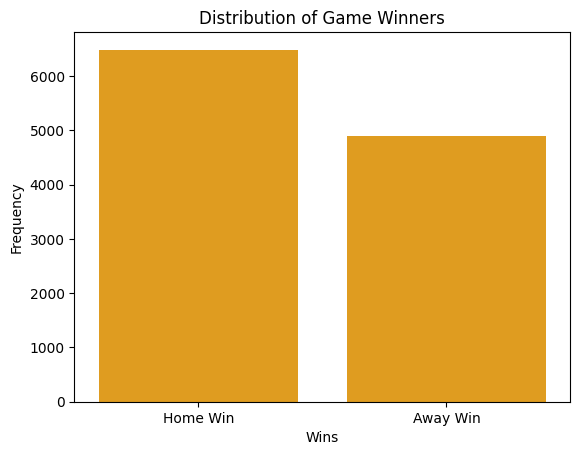

In [8]:
# drop header row
games = games.drop(index=0)

# create winType to distinguish home and away wins from winner column
games['winType'] = games.apply(
    lambda row: 'Home Win' if row['winner'] == row['hometeamId'] else 'Away Win', axis=1)

# countplot of home and away wins
sns.countplot(x='winType', data=games, color='orange')

plt.title('Distribution of Game Winners')
plt.xlabel('Wins')
plt.ylabel('Frequency')
plt.show()

**Figure 3. Distribution of Game Winners.**
This figure represents the number of home wins and away wins.

In [9]:
# count of game winners from figure 3
games['winType'].value_counts()

winType
Home Win    6488
Away Win    4899
Name: count, dtype: int64

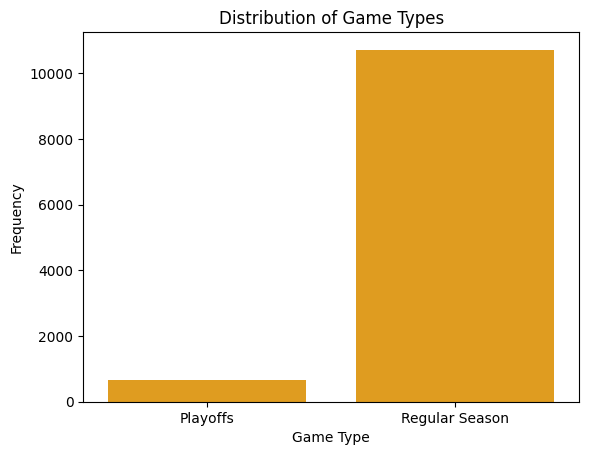

In [10]:
# create gameTypeSpecific to distinguish playoff and regular season games from gameType column
games['gameTypeSpecific'] = games.apply(
    lambda row: 'Regular Season' if row['gameType'] == 'Regular Season' else 'Playoffs', axis=1)

# countplot of playoff and regular season games
sns.countplot(x='gameTypeSpecific', data=games, color='orange')

plt.title('Distribution of Game Types')
plt.xlabel('Game Type')
plt.ylabel('Frequency')
plt.show()

**Figure 4. Distribution of Game Types.** This figure represents the number of playoff and regular season games.

In [11]:
# count of game types from figure 4 
games['gameTypeSpecific'].value_counts()

gameTypeSpecific
Regular Season    10721
Playoffs            666
Name: count, dtype: int64

In [12]:
# create homeWin to distinguish only home wins from winner column
games['homeWin'] = games['winner'] == games['hometeamId']
games['homeWin'] = games['homeWin'].astype(int)

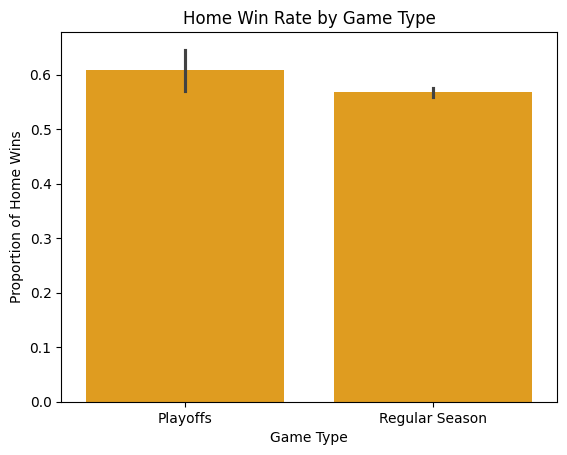

In [13]:
# bar plot of home win proportions by game type
sns.barplot(data=games, x='gameTypeSpecific', y='homeWin', estimator='mean', color='orange')

plt.title('Home Win Rate by Game Type')
plt.xlabel('Game Type')
plt.ylabel('Proportion of Home Wins')
plt.show()

**Figure 5. Home Win Rate by Game Type.** This figure represents the proportion of games won by home teams during the playoffs and regular season.

In [14]:
# summary of figure 5 statistics
games.groupby('gameTypeSpecific')['homeWin'].mean()

gameTypeSpecific
Playoffs          0.608108
Regular Season    0.567391
Name: homeWin, dtype: float64

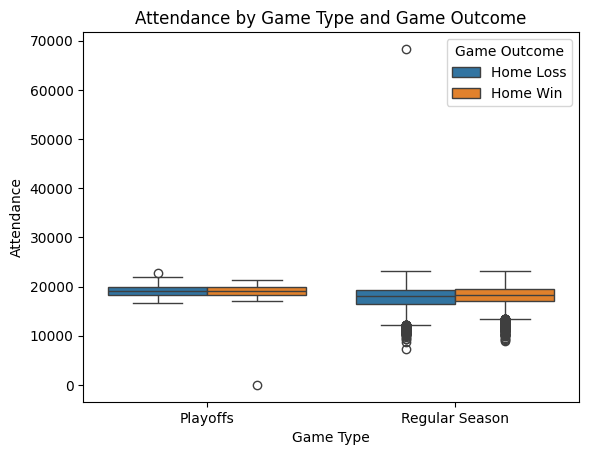

In [15]:
# box plot of attendance by game type and outcome
axes = sns.boxplot(data=games, x='gameTypeSpecific', y='attendance', hue='homeWin')

sns.move_legend(axes, "best", title='Game Outcome', labels=['Home Loss', 'Home Win'])
plt.title('Attendance by Game Type and Game Outcome')
plt.xlabel('Game Type')
plt.ylabel('Attendance')
plt.show()

**Figure 6. Attendance by Game Type and Game Outcome.** This figure represents the attendance of games during playoff and regular season home wins and losses.

In [16]:
# summary of figure 6 statistics
games.groupby(['gameTypeSpecific', 'homeWin'])['attendance'].describe()

count          mean          std      min  \
gameTypeSpecific homeWin                                               
Playoffs         0         261.0  19184.134100  1071.434951  16667.0   
                 1         405.0  19088.227160  1387.867020      0.0   
Regular Season   0        4638.0  17759.341527  2211.426324   7244.0   
                 1        6083.0  18012.689462  1936.599581   8902.0   

                               25%      50%      75%      max  
gameTypeSpecific homeWin                                       
Playoffs         0        18253.00  19156.0  19911.0  22667.0  
                 1        18203.00  19156.0  19812.0  21264.0  
Regular Season   0        16539.25  18064.0  19393.0  68323.0  
                 1        17071.00  18206.0  19520.0  23143.0